# 1. Importación de librerías y configuración

En esta sección se importan las librerías necesarias para realizar la interpretabilidad del modelo mediante la técnica de **Occlusion Sensitivity**. Además, se definen algunos parámetros generales que serán utilizados durante el proceso de visualización.

Las principales librerías empleadas son:

- **TensorFlow/Keras:** para cargar el modelo entrenado y calcular los gradientes.
- **NumPy:** para operaciones numéricas.
- **Matplotlib:** para la visualización de imágenes y mapas de calor.
- **OpenCV:** para el procesamiento y superposición del mapa de calor sobre la imagen original.
- **pathlib:** para acceder de forma sencilla a las imágenes del conjunto de prueba.

En este notebook no se volverá a entrenar la red neuronal. Únicamente se cargará el modelo previamente entrenado (`drowsiness_cnn_unified.keras`) para analizar qué regiones de la imagen fueron más relevantes durante la clasificación.

In [329]:
# ==========================================
# 1. Importación de librerías y configuración
# ==========================================

import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import cv2

from pathlib import Path

# Evitar mensajes innecesarios de TensorFlow
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("TensorFlow:", tf.__version__)

# ------------------------------------------
# Configuración general
# ------------------------------------------

# Tamaño original de entrada del modelo
IMG_SIZE = (48, 48)

# Ruta del modelo entrenado
MODEL_PATH = "drowsiness_cnn_unified.keras"

# Última capa convolucional identificada
LAST_CONV_LAYER = "activation_17"

# Clases del modelo
CLASS_NAMES = ["Drowsy", "Natural"]

print("\nConfiguración cargada correctamente.")
print(f"Modelo: {MODEL_PATH}")
print(f"Última capa convolucional: {LAST_CONV_LAYER}")

TensorFlow: 2.21.0

Configuración cargada correctamente.
Modelo: drowsiness_cnn_unified.keras
Última capa convolucional: activation_17


# 2. Carga del modelo entrenado

En esta sección se carga el modelo previamente entrenado y almacenado en formato `.keras`. Posteriormente, se identifica el bloque **MobileNetV3Small**.

In [330]:
# ==========================================
# 2. Carga del modelo entrenado
# ==========================================

# Cargar el modelo entrenado
model = tf.keras.models.load_model(MODEL_PATH)

print("✓ Modelo cargado correctamente.\n")

# Mostrar arquitectura general
model.summary()

✓ Modelo cargado correctamente.



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ resizing[0][0],   │
│ (Concatenate)       │ 3)                │            │ resizing[0][0],   │
│                     │                   │            │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Small    │ (None, 4, 4, 576) │    939,120 │ concatenate[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 576)       │          0 │ MobileNetV3Small… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 576)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     36,928 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,050,101 (4.01 MB)

 Trainable params: 36,993 (144.50 KB)

 Non-trainable params: 939,120 (3.58 MB)

 Optimizer params: 73,988 (289.02 KB)

In [331]:
# ==========================================
# Localizar el bloque MobileNetV3Small
# ==========================================

# Buscar el modelo base dentro del modelo completo
base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

if base_model is None:
    raise ValueError("No se encontró el modelo base MobileNetV3Small.")

print(f"Modelo base encontrado: {base_model.name}")
print(f"Total de capas: {len(base_model.layers)}")

Modelo base encontrado: MobileNetV3Small
Total de capas: 157


In [332]:
# ==========================================
# Verificar la última capa convolucional
# ==========================================

last_conv_layer = base_model.get_layer(LAST_CONV_LAYER)

print(f"Última capa convolucional: {last_conv_layer.name}")
print(f"Salida de la capa: {last_conv_layer.output.shape}")

Última capa convolucional: activation_17
Salida de la capa: (None, 4, 4, 576)


# 3. Selección de una imagen de prueba

En esta sección se selecciona automáticamente una imagen del conjunto de prueba para realizar la predicción y posteriormente aplicar la técnica de interpretabilidad.

In [333]:
# ==========================================
# Buscar imágenes disponibles
# ==========================================

from pathlib import Path

# Cambia únicamente esta ruta si tu dataset está en otra ubicación
TEST_PATH = Path("datasets/Unified_Drowsiness_Dataset/test")

print("Carpetas encontradas:")

for folder in TEST_PATH.iterdir():
    if folder.is_dir():
        print("-", folder.name)

Carpetas encontradas:
- Drowsy
- Natural


In [334]:
# ==========================================
# Mostrar cuántas imágenes existen
# ==========================================

drowsy_images = list((TEST_PATH / "Drowsy").glob("*"))
natural_images = list((TEST_PATH / "Natural").glob("*"))

print("Drowsy:", len(drowsy_images))
print("Natural:", len(natural_images))

Drowsy: 8318
Natural: 7898


### Selección automática de imágenes

Se define una función que permite seleccionar imágenes de cualquiera de las clases del conjunto de prueba. Esto facilita generar mapas Grad-CAM para distintos ejemplos sin modificar el código.

In [335]:
# ==========================================
# Función para seleccionar imágenes
# ==========================================

import random

def get_random_image(class_name=None):
    """
    Devuelve una imagen aleatoria del conjunto de prueba.

    Parámetros
    ----------
    class_name : str
        "Drowsy", "Natural" o None.

    Retorna
    -------
    pathlib.Path
    """

    if class_name is None:

        all_images = drowsy_images + natural_images
        return random.choice(all_images)

    elif class_name == "Drowsy":

        return random.choice(drowsy_images)

    elif class_name == "Natural":

        return random.choice(natural_images)

    else:

        raise ValueError(
            "La clase debe ser 'Drowsy', 'Natural' o None."
        )

### Selección automática de imágenes

Se define una función que permite seleccionar imágenes de cualquiera de las clases del conjunto de prueba. Esto facilita generar mapas Grad-CAM para distintos ejemplos sin modificar el código.

In [336]:
# ==========================================
# Seleccionar imagen
# ==========================================

# Opciones:
# "Drowsy"
# "Natural"
# None  -> Imagen aleatoria

SELECT_CLASS = "Natural"

selected_image = get_random_image(SELECT_CLASS)

print("Imagen seleccionada:")
print(selected_image)

Imagen seleccionada:
datasets\Unified_Drowsiness_Dataset\test\Natural\MRL_39310.jpg


# 4. Predicción de la imagen seleccionada

En esta sección se carga la imagen seleccionada, se realiza la predicción con el modelo entrenado y se visualizan la clase real, la clase predicha y la probabilidad asociada. Esta información permitirá analizar posteriormente las regiones relevantes para la clasificación.

In [337]:
# ==========================================
# Función para cargar una imagen
# ==========================================

def load_image(image_path):
    """
    Carga una imagen y la prepara para el modelo.
    """

    image = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=IMG_SIZE
    )

    image = tf.keras.utils.img_to_array(image)

    image = image.astype(np.float32) / 255.0

    image_batch = np.expand_dims(image, axis=0)

    return image, image_batch   

In [338]:
# ==========================================
# Cargar imagen seleccionada
# ==========================================

image, image_batch = load_image(selected_image)

print("Imagen cargada correctamente.")
print("Dimensiones:", image_batch.shape)

Imagen cargada correctamente.
Dimensiones: (1, 48, 48, 1)


In [339]:
# ==========================================
# Predicción
# ==========================================

prediction = model.predict(image_batch, verbose=0)[0][0]

predicted_class = 1 if prediction >= 0.5 else 0

predicted_label = CLASS_NAMES[predicted_class]

confidence = prediction if predicted_class == 1 else (1 - prediction)

In [340]:
# ==========================================
# Obtener clase real
# ==========================================

real_label = selected_image.parent.name

print(f"Clase real      : {real_label}")
print(f"Clase predicha  : {predicted_label}")
print(f"Confianza       : {confidence*100:.2f}%")

Clase real      : Natural
Clase predicha  : Drowsy
Confianza       : 99.94%


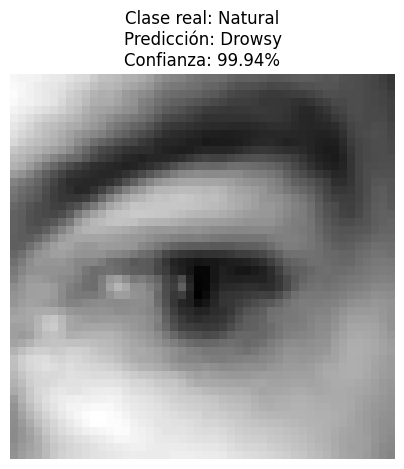

In [341]:
# ==========================================
# Mostrar imagen
# ==========================================

plt.figure(figsize=(5,5))

plt.imshow(image.squeeze(), cmap="gray")

plt.title(
    f"Clase real: {real_label}\n"
    f"Predicción: {predicted_label}\n"
    f"Confianza: {confidence*100:.2f}%"
)

plt.axis("off")

plt.show()

# 5. Implementación de Occlusion Sensitivity

En esta sección se implementa la técnica **Occlusion Sensitivity**, la cual permite identificar las regiones más importantes para la decisión del modelo.

El procedimiento consiste en ocultar sistemáticamente pequeñas regiones de la imagen mediante una ventana deslizante. Después de cada oclusión se realiza nuevamente la predicción y se mide la variación en la confianza del modelo.

Las regiones cuya oclusión produce una mayor disminución en la probabilidad de la clase predicha se consideran las más relevantes durante el proceso de clasificación.

In [342]:
# ==========================================
# Parámetros de Occlusion Sensitivity
# ==========================================

# Tamaño del parche que ocultará parte de la imagen
PATCH_SIZE = 8

# Desplazamiento entre ventanas
STRIDE = 2

print("Patch Size :", PATCH_SIZE)
print("Stride     :", STRIDE)

Patch Size : 8
Stride     : 2


In [343]:
# ==========================================
# Predicción original
# ==========================================

original_prediction = model.predict(
    image_batch,
    verbose=0
)[0][0]

print(f"Predicción original: {original_prediction:.4f}")

Predicción original: 0.0006


In [344]:
# ==========================================
# Función Occlusion Sensitivity
# ==========================================

def occlusion_sensitivity(
    model,
    image_batch,
    patch_size=8,
    stride=2
):
    """
    Genera un mapa de sensibilidad mediante
    Occlusion Sensitivity.
    """

    image = image_batch.copy()

    h, w = image.shape[1:3]

    baseline = model.predict(
        image,
        verbose=0
    )[0][0]

    sensitivity = np.zeros((h, w))

    for y in range(0, h-patch_size+1, stride):

        for x in range(0, w-patch_size+1, stride):

            occluded = image.copy()

            occluded[
                :,
                y:y+patch_size,
                x:x+patch_size,
                :
            ] = 0

            prediction = model.predict(
                occluded,
                verbose=0
            )[0][0]

            change = abs(
                baseline - prediction
            )

            sensitivity[
                y:y+patch_size,
                x:x+patch_size
            ] += change

    sensitivity -= sensitivity.min()

    sensitivity /= (
        sensitivity.max()
        + 1e-8
    )

    return sensitivity

In [345]:
# ==========================================
# Generar mapa de sensibilidad
# ==========================================

heatmap = occlusion_sensitivity(

    model,

    image_batch,

    patch_size=PATCH_SIZE,

    stride=STRIDE

)

print("Mapa generado correctamente.")
print(heatmap.shape)

Mapa generado correctamente.
(48, 48)


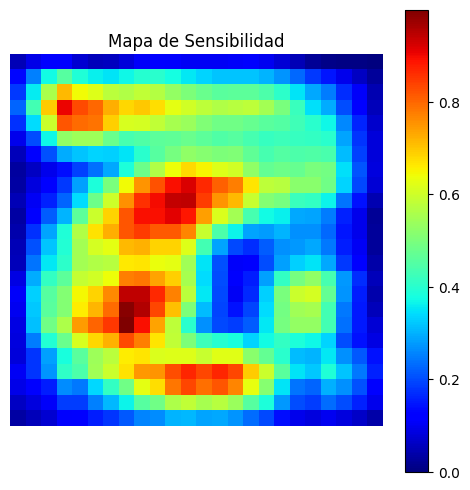

In [346]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.title("Mapa de Sensibilidad")

plt.colorbar()

plt.axis("off")

plt.show()

# 6. Visualización del mapa de sensibilidad

En esta sección el mapa de sensibilidad obtenido se superpone sobre la imagen original para visualizar las regiones que tuvieron mayor influencia durante la clasificación.

Las zonas representadas en colores cálidos indican que la confianza del modelo disminuyó significativamente cuando dichas regiones fueron ocultadas, mientras que los colores fríos representan áreas con menor impacto en la predicción.

In [347]:
# ==========================================
# Superponer mapa de calor
# ==========================================

def overlay_heatmap(
    image,
    heatmap,
    alpha=0.45
):

    heatmap_uint8 = np.uint8(
        heatmap * 255
    )

    heatmap_color = cv2.applyColorMap(

        heatmap_uint8,

        cv2.COLORMAP_JET

    )

    image_uint8 = np.uint8(
        image.squeeze()*255
    )

    image_rgb = cv2.cvtColor(

        image_uint8,

        cv2.COLOR_GRAY2RGB

    )

    overlay = cv2.addWeighted(

        image_rgb,

        1-alpha,

        heatmap_color,

        alpha,

        0

    )

    return heatmap_color, overlay

In [348]:
# ==========================================
# Crear visualización final
# ==========================================

heatmap_color, overlay = overlay_heatmap(

    image,

    heatmap

)

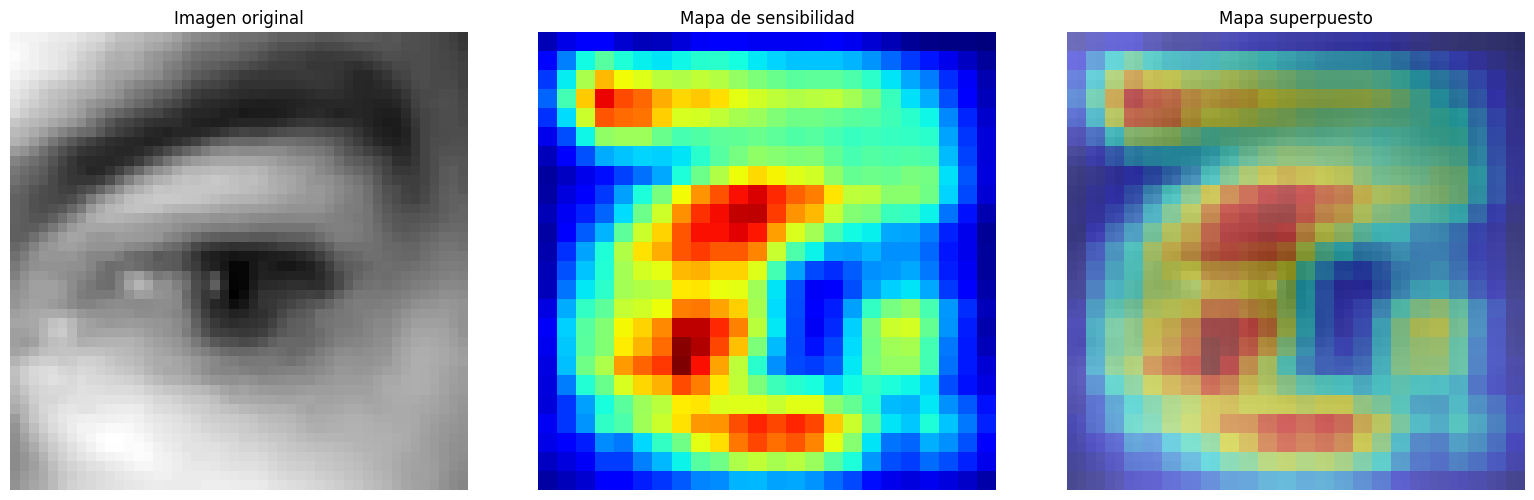

In [349]:
# ==========================================
# Mostrar resultados
# ==========================================

fig, ax = plt.subplots(

    1,

    3,

    figsize=(16,5)

)

ax[0].imshow(
    image.squeeze(),
    cmap="gray"
)
ax[0].set_title("Imagen original")
ax[0].axis("off")

ax[1].imshow(
    heatmap,
    cmap="jet"
)
ax[1].set_title("Mapa de sensibilidad")
ax[1].axis("off")

ax[2].imshow(
    overlay[..., ::-1]
)
ax[2].set_title("Mapa superpuesto")
ax[2].axis("off")

plt.tight_layout()

plt.show()

# 7. Análisis de múltiples ejemplos

En esta sección se analiza un conjunto de imágenes pertenecientes a ambas clases del problema (**Drowsy** y **Natural**) utilizando la técnica de Occlusion Sensitivity.

Para cada imagen se presentan:

- Imagen original.
- Clase real.
- Clase predicha.
- Nivel de confianza.
- Mapa de sensibilidad.
- Superposición del mapa de sensibilidad.

Este análisis permite verificar si las regiones consideradas importantes por el modelo son consistentes entre diferentes ejemplos y comparar el comportamiento de la red para ambas clases.

In [354]:
# ==========================================
# Función para analizar una imagen
# ==========================================

def analyze_image(image_path):

    image, image_batch = load_image(image_path)

    prediction = model.predict(
        image_batch,
        verbose=0
    )[0][0]

    predicted_class = 1 if prediction >= 0.5 else 0

    predicted_label = CLASS_NAMES[predicted_class]

    confidence = (
        prediction
        if predicted_class
        else (1 - prediction)
    )

    heatmap = occlusion_sensitivity(
        model,
        image_batch,
        patch_size=8,
        stride=4
    )

    heatmap_color, overlay = overlay_heatmap(
        image,
        heatmap
    )

    return (
        image,
        heatmap_color,
        overlay,
        predicted_label,
        confidence,
        image_path.parent.name
    )

In [355]:
# ==========================================
# Configuración
# ==========================================

NUM_IMAGES = 4

selected_drowsy = random.sample(
    drowsy_images,
    NUM_IMAGES
)

selected_natural = random.sample(
    natural_images,
    NUM_IMAGES
)

In [356]:
# ==========================================
# Visualización para ambas clases
# ==========================================

def show_examples(image_list, title):

    fig, axes = plt.subplots(
        len(image_list),
        3,
        figsize=(12, len(image_list)*4)
    )

    if len(image_list) == 1:
        axes = np.expand_dims(
            axes,
            axis=0
        )

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold"
    )

    for i, image_path in enumerate(image_list):

        (
            image,
            heatmap,
            overlay,
            pred,
            conf,
            real
        ) = analyze_image(image_path)

        # -------------------------
        # Imagen original
        # -------------------------

        axes[i,0].imshow(
            image.squeeze(),
            cmap="gray"
        )

        axes[i,0].set_title(
            f"Real: {real}\nPred: {pred}"
        )

        axes[i,0].axis("off")

        # -------------------------
        # Heatmap
        # -------------------------

        axes[i,1].imshow(
            heatmap[...,::-1]
        )

        axes[i,1].set_title(
            "Mapa de sensibilidad"
        )

        axes[i,1].axis("off")

        # -------------------------
        # Overlay
        # -------------------------

        axes[i,2].imshow(
            overlay[...,::-1]
        )

        axes[i,2].set_title(
            f"Confianza: {conf*100:.2f}%"
        )

        axes[i,2].axis("off")

    plt.tight_layout()

    plt.show()

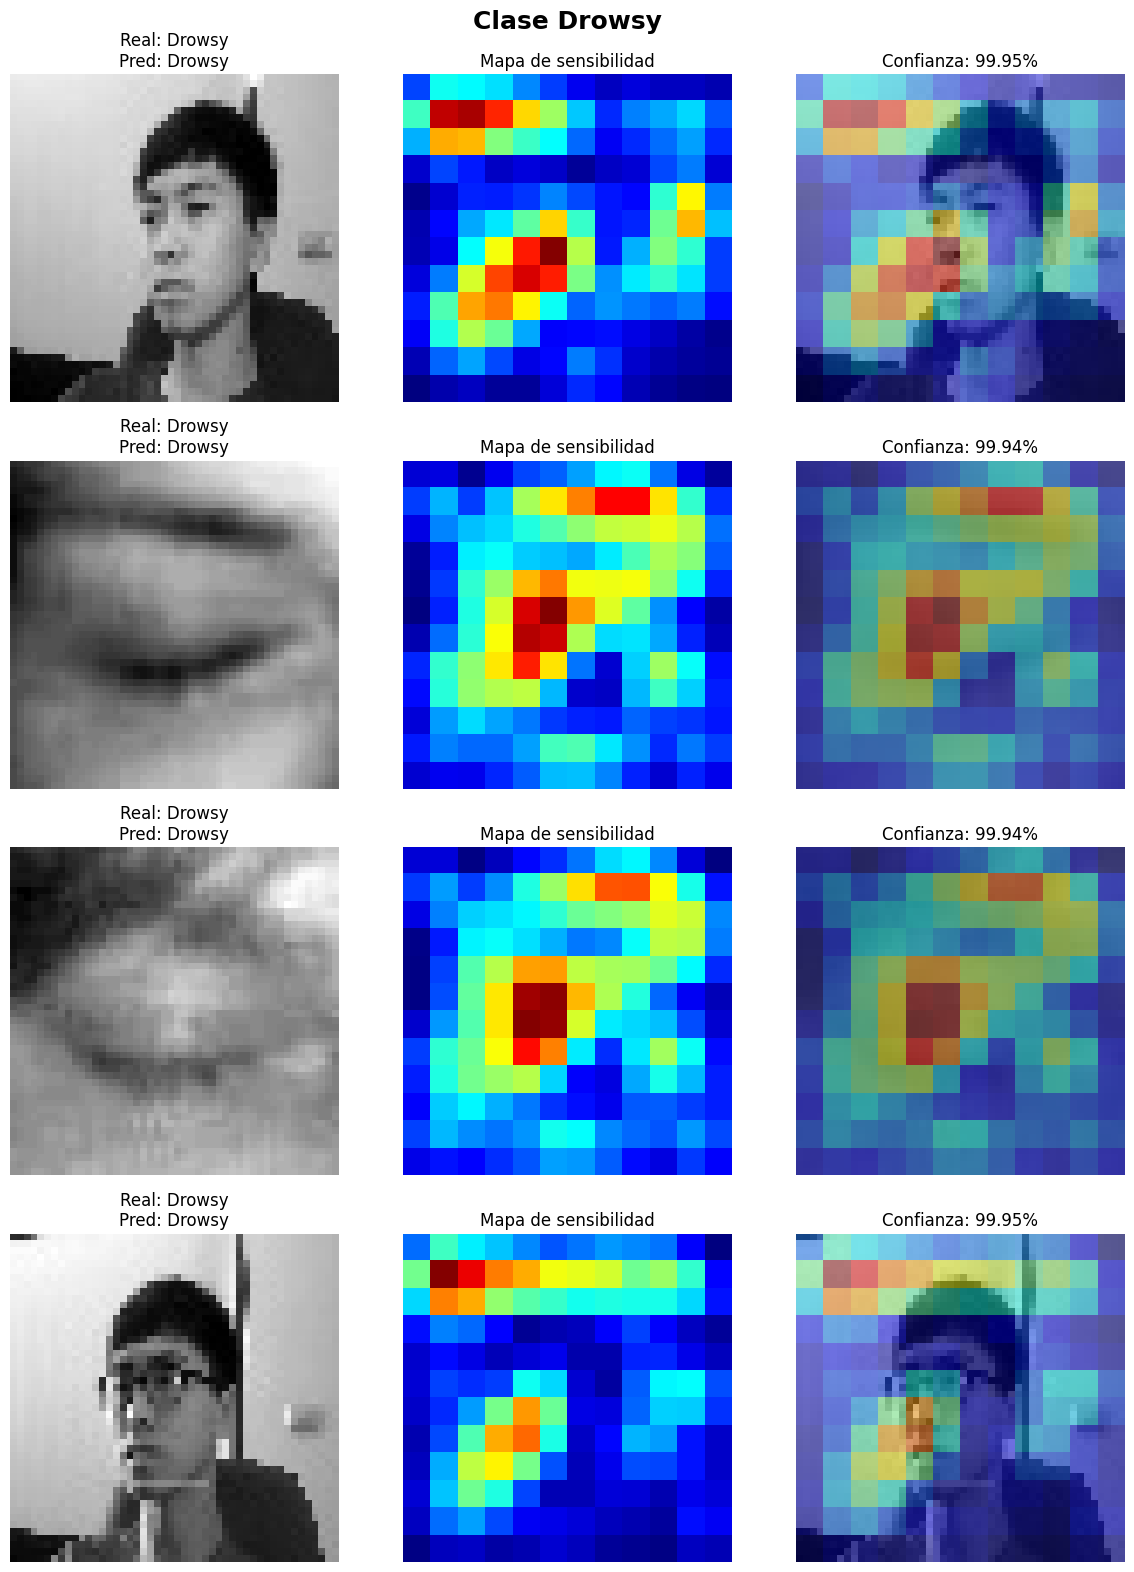

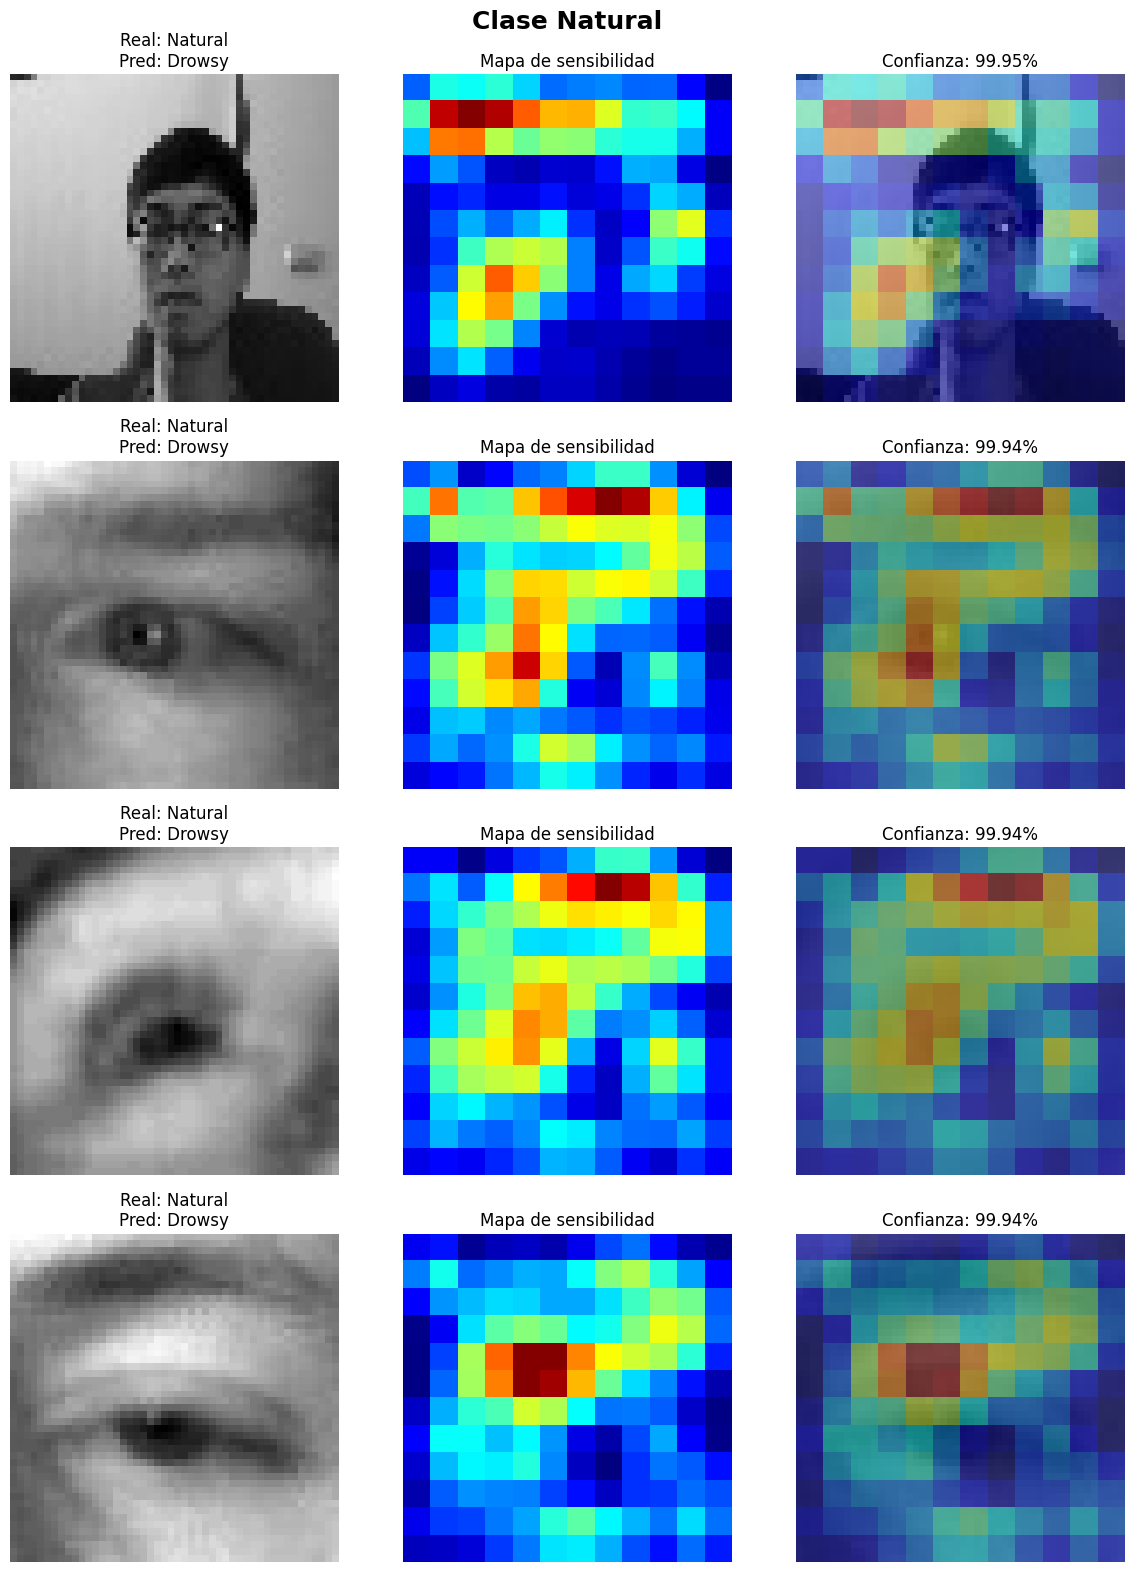

In [357]:
# ==========================================
# Mostrar ejemplos Drowsy
# ==========================================

show_examples(
    selected_drowsy,
    "Clase Drowsy"
)

# ==========================================
# Mostrar ejemplos Natural
# ==========================================

show_examples(
    selected_natural,
    "Clase Natural"
)